# 0000 Compare Multisource Coverage Tiles

这个 notebook 用来对 `0003` 里同一区域、同一 display zoom 的多源 coverage tile 做统一召回与并排可视化比较。

- 默认模式：直接读取 `data/raw` 里已经抓好的历史结果。
- `FETCH_LIVE = True`：按当前配置重新抓取各 provider 的 coverage tiles。
- Apple Look Around 在这里固定使用指定 `DISPLAY_ZOOM`，不走 auto zoom，这样便于和其他源同级比较。

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

PROJECT_ROOT = Path("/data/zicheng/2026_global_street_view_coverage")
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from coverage_acquisition import BoundingBox, bbox_from_preset, fetch_single_source, maybe_dataframe
from coverage_acquisition.visualization import (
    load_results_from_manifest_paths,
    plot_multi_provider_comparison,
    summarize_results,
)


## Config

把这里当成中控面板：区域、zoom、subbox、provider、是否重新召回，都在这一格里改。

In [2]:
OUTPUT_ROOT = PROJECT_ROOT / "data" / "raw"

PROVIDERS = (
    "apple_lookaround",
    "svmap_google",
    "kartaview",
    "panoramax",
    "mapillary",
    "yandex",
)

USE_CUSTOM_BBOX = True
CUSTOM_BBOX = (
    4.438112114771149,
    51.882704386297235,
    4.572152750451489,
    51.94038576773118,
)
# order: (min_lon, min_lat, max_lon, max_lat)

AREA_PRESET = "amsterdam_city_bbox_approx"
DISPLAY_ZOOM = 13
GRID_ROWS = 1
GRID_COLS = 1
TARGET_SUBBOXES = None
# Whole bbox: GRID_ROWS = 1, GRID_COLS = 1, TARGET_SUBBOXES = None
# 3x3 all subboxes: GRID_ROWS = 3, GRID_COLS = 3, TARGET_SUBBOXES = None
# 3x3 only first subbox: GRID_ROWS = 3, GRID_COLS = 3, TARGET_SUBBOXES = (0,)
RUN_TAG = "amsterdam_compare_z13"
BBOX_PAD_FRACTION = 0.0
# 0.0 means the plot window matches the input bbox exactly.
# Increase slightly, e.g. 0.05, only if you want extra margin around the bbox.

FETCH_LIVE = True

ACCESS_TOKENS = {
    "mapillary": "MLY|8443722902364390|832fa01211e391f5fd88c8a6186d2ff8",
}

EXISTING_MANIFEST_PATHS = {
    "apple_lookaround": OUTPUT_ROOT / "apple_lookaround_bluelines_layered" / "amsterdam_city_grid_layered_subbox_00" / "manifest.json",
    "svmap_google": OUTPUT_ROOT / "svmap_google_mts_raster" / "amsterdam_city_grid_svmap_mts_subbox_00" / "manifest.json",
    "kartaview": OUTPUT_ROOT / "kartaview_coverage_raster" / "amsterdam_city_grid_kartaview_subbox_00" / "manifest.json",
    "panoramax": OUTPUT_ROOT / "panoramax_mvt_coverage" / "amsterdam_city_grid_panoramax_subbox_00" / "manifest.json",
    "mapillary": OUTPUT_ROOT / "mapillary_mvt_coverage" / "amsterdam_city_grid_mapillary_subbox_00" / "manifest.json",
    "yandex": OUTPUT_ROOT / "yandex_stv_raster" / "amsterdam_compare_z13_yandex_subbox_00" / "manifest.json",
}

if USE_CUSTOM_BBOX:
    BBOX = BoundingBox.from_sequence(CUSTOM_BBOX)
    BBOX_SOURCE = "custom_bbox"
else:
    BBOX = bbox_from_preset(AREA_PRESET)
    BBOX_SOURCE = f"preset:{AREA_PRESET}"

print("BBOX_SOURCE:", BBOX_SOURCE)
print("GRID:", (GRID_ROWS, GRID_COLS))
print("TARGET_SUBBOXES:", TARGET_SUBBOXES)
BBOX


BBOX_SOURCE: custom_bbox
GRID: (1, 1)
TARGET_SUBBOXES: None


BoundingBox(min_lon=4.438112114771149, min_lat=51.882704386297235, max_lon=4.572152750451489, max_lat=51.94038576773118)

## Recall

- `FETCH_LIVE = False` 时，直接读取 `EXISTING_MANIFEST_PATHS`。
- `FETCH_LIVE = True` 时，按同一 `DISPLAY_ZOOM` 重新抓取。

In [3]:
if GRID_ROWS > 1 or GRID_COLS > 1:
    if TARGET_SUBBOXES is None:
        print("Subdivision is enabled and all subboxes will be fetched.")
    else:
        print(f"Subdivision is enabled and only these subboxes will be fetched: {TARGET_SUBBOXES}")
else:
    print("Whole bbox mode: no subdivision.")

if FETCH_LIVE:
    active_providers = list(PROVIDERS)
    if "mapillary" in active_providers and not ACCESS_TOKENS.get("mapillary"):
        active_providers.remove("mapillary")
        print("Mapillary token is empty; skipped live fetch for mapillary.")

    bundles = []
    for provider in active_providers:
        bundle = fetch_single_source(
            provider=provider,
            bbox=BBOX,
            output_root=OUTPUT_ROOT,
            display_zoom=DISPLAY_ZOOM,
            auto_zoom=False,
            grid_rows=GRID_ROWS,
            grid_cols=GRID_COLS,
            target_subboxes=TARGET_SUBBOXES,
            run_label=f"{RUN_TAG}_{provider}",
            access_token=ACCESS_TOKENS.get(provider),
            dry_run=False,
        )
        bundles.append(bundle)

    comparison_results = [
        result
        for bundle in bundles
        for result in bundle["results"]
    ]
else:
    comparison_results = load_results_from_manifest_paths(
        [EXISTING_MANIFEST_PATHS[provider] for provider in PROVIDERS]
    )

len(comparison_results)


Whole bbox mode: no subdivision.


5

## Summary

In [4]:
summary_rows = summarize_results(comparison_results)
summary_table = maybe_dataframe(summary_rows)
summary_table


,provider,source_id,source_kind,job_index,display_zoom,source_zoom,tile_count,pano_record_count,vector_feature_record_count,aggregate_coverage_ratio,manifest_path
0,apple_lookaround,apple_lookaround_cached_bluelines,vector_mvt,0,13,13,15,0,5042,NaN,/data/zicheng/2026_global_street_view_coverage...
1,svmap_google,svmap_google_mts,raster,0,13,13,15,0,0,0.602195,/data/zicheng/2026_global_street_view_coverage...
2,kartaview,kartaview_sequence_tiles,raster,0,13,13,15,0,0,0.014749,/data/zicheng/2026_global_street_view_coverage...
3,panoramax,panoramax_xyz_mvt,vector_mvt,0,13,13,15,0,107,NaN,/data/zicheng/2026_global_street_view_coverage...
4,mapillary,mapillary_mly1_public_vtp,vector_mvt,0,13,13,15,0,6438,NaN,/data/zicheng/2026_global_street_view_coverage...


## Visualization

每个 panel 都使用同一个 bbox 范围，便于直观看 coverage 密度、分布和边界差异。

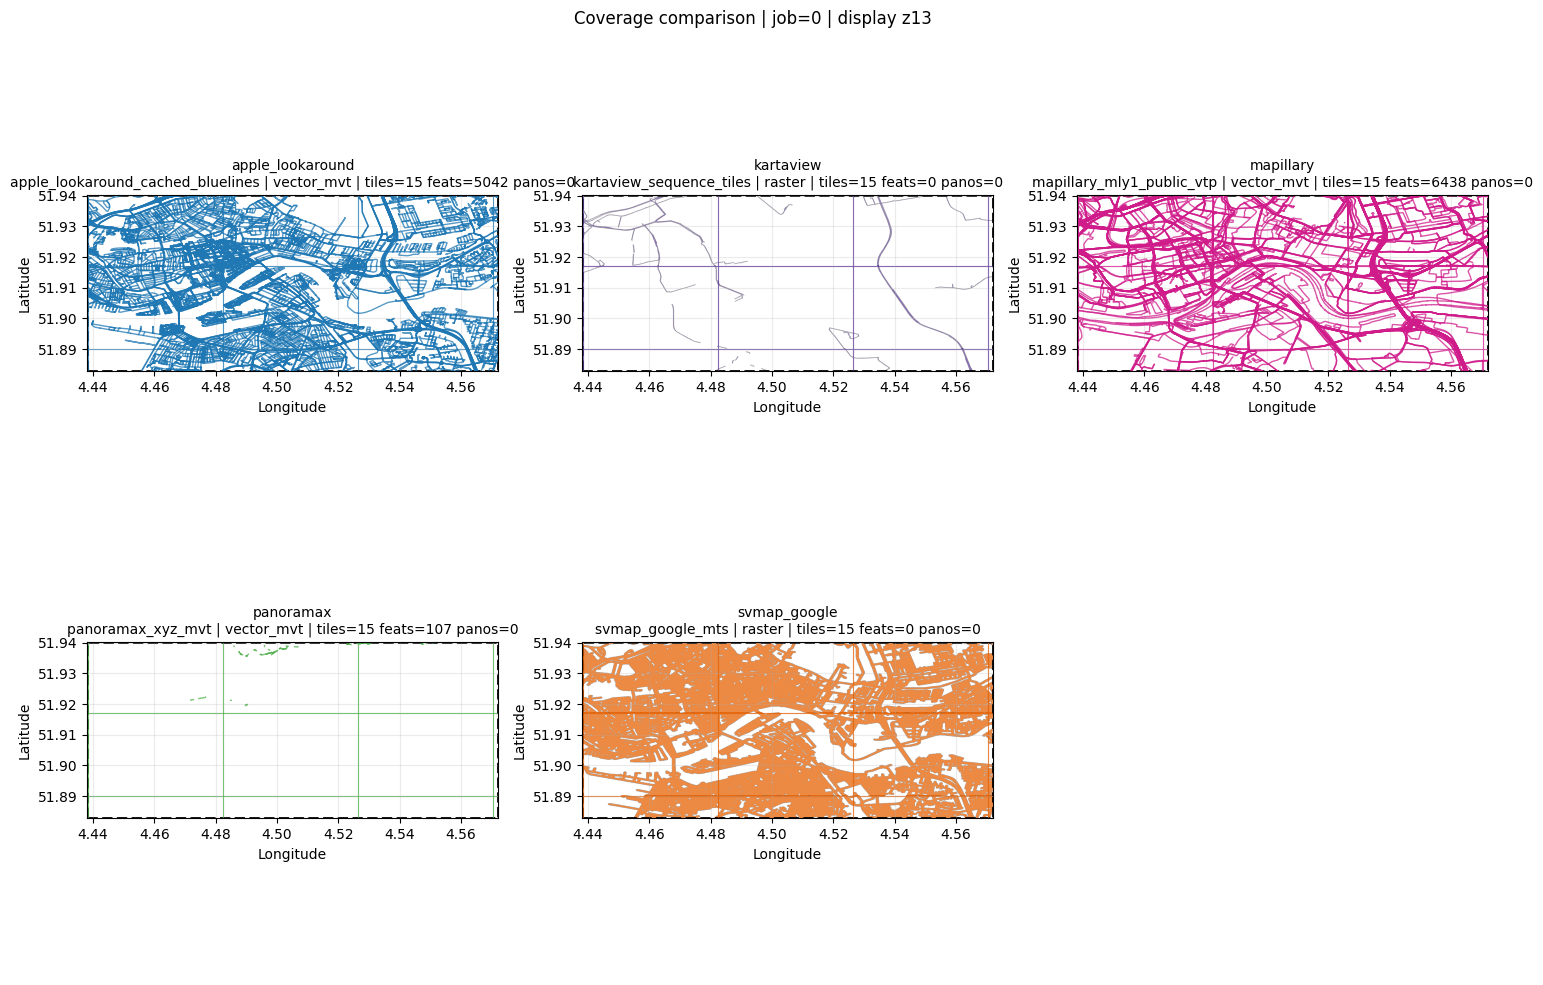

In [5]:
for job_index in sorted({result["job"]["index"] for result in comparison_results}):
    plot_multi_provider_comparison(
        comparison_results,
        job_index=job_index,
        ncols=3,
        figsize_per_panel=(5.0, 5.0),
        show_tile_frames=True,
        show_tile_labels=False,
        bbox_pad_fraction=BBOX_PAD_FRACTION,
        suptitle=f"Coverage comparison | job={job_index} | display z{DISPLAY_ZOOM}",
    )


## Notes

- 如果你要手动输入 bbox，把 `USE_CUSTOM_BBOX = True`，再修改 `CUSTOM_BBOX = (min_lon, min_lat, max_lon, max_lat)`。
- 如果你仍然想用预设区域，保持 `USE_CUSTOM_BBOX = False`，再改 `AREA_PRESET`。
- 当前可视化默认 `BBOX_PAD_FRACTION = 0.0`，也就是显示窗口严格贴合输入 bbox。
- 如果你要严格控制各源同一 zoom 对比，保持 `auto_zoom=False`。
- Yandex is now available as provider key `yandex`; it uses the Yandex WGS84 elliptic Mercator tile grid internally.
- 如果后面新增 provider，只要它已经注册进 `coverage_acquisition.providers`，这里通常只需要把 provider key 加进 `PROVIDERS`。
